# BPT-MOTUS (vs. other methods) Example

# Load Data
## Load data

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

%env CUDA_DEVICE_ORDER=PCI_BUS_ID
%env CUDA_VISIBLE_DEVICES=1
!export BART_CPU_ONLY=1
!export CUDA_LAUNCH_BLOCKING=1

import sys
import os

os.environ['BART_TOOLBOX_PATH'] = '/home/rinbha/Packages/bart-0.9.00'
os.environ['BART_CPU_ONLY'] = '1'
sys.path.append(os.path.join(os.environ['BART_TOOLBOX_PATH'], 'python'))

sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/nonrigid-motion-bpt")
sys.path.insert(0, "/home/rinbha/Research/BPT/BPT_MOTUS/bpt_mrmotus_2025/bpt_mrmotus_2025/mrmotus_custom_packages/torch-interpol")

import matplotlib.pyplot as plt
# plotting
plt.rcParams.update({
    'axes.spines.top': False,           # Remove top spine
    'axes.spines.right': False,         # Remove right spine
    'axes.titlesize': 20,               # Increase title font size
    'axes.labelsize': 18,               # Increase axis label font size
    'xtick.labelsize': 16,              # Increase x-tick label size
    'ytick.labelsize': 16,              # Increase y-tick label size
    "text.usetex": False,                # Enable LaTeX 
    'legend.fontsize': 12,
    'font.family': 'Avenir' # Avenir font
})

env: CUDA_DEVICE_ORDER=PCI_BUS_ID
env: CUDA_VISIBLE_DEVICES=1


In [3]:
from bpt_motus.io import RadialArchive

# Point to raw radial scan target
base_dir = "/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus"
inpdir = f"{base_dir}/hires_ute" 
radial = RadialArchive(inp_dir=inpdir)
# radial.get_ksp(force_reload=False)

# print(f"xk_time: {radial.xk_time.shape}")
# print(f"coords_time: {radial.coords_time.shape}")
# print(f"dcf_time: {radial.dcf_time.shape}")

## Organize radial scan

In [4]:
from bpt_motus.io import SplitRadialAcq

split_exp = SplitRadialAcq(
    inp_dir=base_dir,
    calib_source="hires",
    no_motion_range=(0, 15000),
    calib_range=(20000, 35000),
    inf_range=(35000, None),
    verbose=True
)
split_exp.run(force_reload=False)

INFO: Found split datasets. No need to split again.


# Process Data
## Split k-space and BPT

In [9]:
from bpt_motus.preprocessing import SplitXkBPT

splitter_nm = SplitXkBPT(inp_dir=split_exp.no_motion_dir, verbose=True)
splitter_nm.run(force_reload=True)

# Run again for the calibration and inference datasets, using the PCA model estimated from the no-motion dataset
for d in [split_exp.calib_dir, split_exp.inf_dir]:
    splitter = SplitXkBPT(inp_dir=d, pca_fname=splitter_nm.pca_fname, verbose=True)
    splitter.run(force_reload=True)

INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [00:44<00:00, 334.16it/s]
INFO: Aligning k-space.
INFO: Extracting BPT/PTs.
INFO: Cleaning k-space, still aligned.
INFO: Unaligning cleaned k-space.
INFO: Coil compressing k-space with PCA.
INFO: No PCA model provided or found. Estimating new PCA model.
INFO: Saving PCA model to /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/no_motion/xk_pca.npy.
INFO: Cleaned k-space and raw BPT/PT signals not found. Extracting...
INFO: Getting raw time-ordered k-space.
INFO: Getting hybrid raw k-space.
INFO: Getting coarse peaks.
INFO: Getting strongest tone.
INFO: Getting offsets.
100%|████████████████████████████████████████████████████████████████████████

## Process B+PT signals

In [17]:
from bpt_motus.preprocessing import ProcessBPT

proc_c = ProcessBPT(inp_dir=split_exp.calib_dir, verbose=True, phase="calib")
proc_c.run(force_reload=True)

proc_i = ProcessBPT(inp_dir=split_exp.inf_dir, verbose=True, phase="inf")
proc_i.run(force_reload=True)

INFO: Processed BPT/PTs not found. Extracting them...


INFO: TR found from metadata: 5.85 ms
INFO: Loading raw BPT/PTs...
INFO: Applying median filter to BPT/PTs...
INFO: Applying low-pass filter to BPT/PTs...
INFO: Applying SSA to BPT/PTs...
SSA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:07<00:00, 11.38it/s]
INFO: Normalizing BPT/PTs...
INFO: Applying PCA to BPT/PTs...
INFO: Processed BPT/PTs not found. Extracting them...
INFO: TR found from metadata: 5.85 ms
INFO: Loading raw BPT/PTs...
INFO: Applying median filter to BPT/PTs...
INFO: Applying low-pass filter to BPT/PTs...
INFO: Applying SSA to BPT/PTs...
SSA: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [00:03<00:00, 26.65it/s]
INFO: Normalizing BPT/PTs...
INFO: Applying PCA to BPT/PTs...


## Process no-motion data

In [23]:
from bpt_motus.preprocessing import NoMotionReference

nomotion_ref = NoMotionReference(inp_dir=split_exp.no_motion_dir, verbose=True, crop_factor=3, center_out=False)
nomotion_ref.run(force_reload=True)

print(f"Reference Image shape: {nomotion_ref.S.shape}")
print(f"CSM shape: {nomotion_ref.csm.shape}")

INFO: Reference image and CSMs not found. Extracting with crop factor 3...
INFO: Getting xk, coords, dcf from radial data.
INFO: Cropping spokes by 3.
INFO: Preparing adjoint NUFFT operator and inputs.
INFO: Getting cartesian k-space of reference.
INFO: Getting coil sensitivity maps of reference.
INFO: Getting reference image.


Done.


SenseRecon:   0%|          | 0/30 [00:00<?, ?it/s]

Reference Image shape: (135, 135, 135)
CSM shape: (6, 135, 135, 135)


## Process motion data

In [30]:
from bpt_motus.preprocessing import MotionFrames

mf_c = MotionFrames(inp_dir=split_exp.calib_dir, verbose=True)
mf_c.run(force_reload=True)

mf_i = MotionFrames(inp_dir=split_exp.inf_dir, verbose=True)
mf_i.run(force_reload=True)

# Assertion check verifying temporal sizes (Nframes) match perfectly
assert mf_c.xk_frames.shape[1] == mf_c.bpts_frames.shape[0], "Calibration temporal sizes do not match!"
assert mf_i.xk_frames.shape[1] == mf_i.bpts_frames.shape[0], "Inference temporal sizes do not match!"
print("Motion frames and BPT temporal sizes match perfectly.")

INFO: Radial acquisition split into frames not found. Extracting with crop factor 8...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 8.
INFO: Splitting radial data into frames.
INFO: Radial acquisition split into frames not found. Extracting with crop factor 8...
INFO: Getting xk, coords, dcf, and bpts from radial data.
INFO: Cropping spokes by 8.
INFO: Splitting radial data into frames.


Motion frames and BPT temporal sizes match perfectly.


# Learn motion fields
## Run optimization on calibration data

None


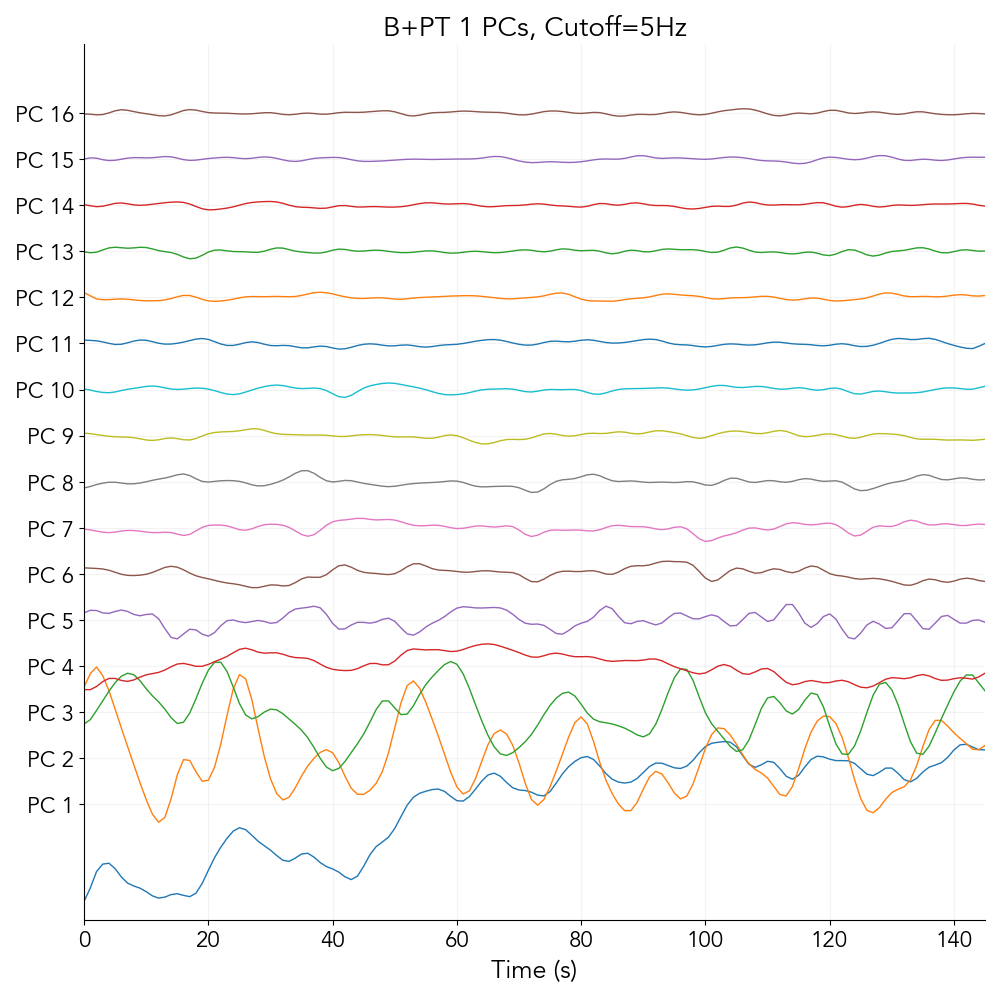

In [108]:
from bpt_motus.viz import BPTVisualizer
bv = BPTVisualizer(bpts=optimizer.bpt_frames)
bv.plot_bpts()

In [ ]:
from bpt_motus.motion import MotionFieldOptimizer

optimizer = MotionFieldOptimizer(
    calib_inpdir=mf_c.save_dir,
    nomotion_inpdir=nomotion_ref.save_dir,
    mode='mrmotus',
    xyz_downsampling=[4, 8, 16],
    t_downsampling=[2,5],
    max_t_init=0.5,
    epochs=20,
    batch_size=50,
    learning_rate=5e-2,
    device='cuda',
    verbose=True,
    force_reload=True
)
optimizer.optimize()

INFO: MotionFieldModel initialized: mode=bpt_motus, shape=torch.Size([135, 135, 135]), frames=146
INFO: Initializing BPT-MOTUS mode...
INFO: Building spatial B-spline bases: nx=135, ny=135, nz=135, factors=[4, 8, 16]
INFO: Best parameters weren't found at /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus, running the optimization.
INFO: Calculating scaling per frame dynamically...
  5%|█████▎                                                                                                     | 1/20 [03:32<1:07:23, 212.82s/it]
INFO: Saving best parameters from epoch 0 and logs to /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus...


In [107]:
np.linalg.norm(nomotion_ref.S)

111748.0415385116

In [85]:
import torch

frame_id = 10  # pick whichever frame you want

# scaling_per_frame isn't cached across reloads -- recompute it (deterministic, zero-motion based)
if optimizer.scaling_per_frame is None:
    scaling = optimizer._compute_scaling_per_frame()
    optimizer.scaling_per_frame = torch.from_numpy(scaling).to(optimizer.device).to(torch.complex64)

coords_frame = torch.from_numpy(optimizer.coords_frames[frame_id]).to(optimizer.device).to(torch.float32).unsqueeze(0)

with torch.no_grad():
    mf_frame = optimizer.motion_model.forward([frame_id])      # motion field for this frame
    S_warped = optimizer._warp_img(mf_frame)                    # reference warped by that field
    k_pred = optimizer._forward_model(S_warped, coords_frame) * optimizer.scaling_per_frame[frame_id]

xk_actual = torch.from_numpy(optimizer.xk_frames[:, frame_id]).to(optimizer.device).to(torch.complex64).unsqueeze(0)

# both are shape (1, ncoils, spokes, samples)
k_pred = k_pred.squeeze(0).cpu().numpy()       # -> (ncoils, spokes, samples)
xk_actual = xk_actual.squeeze(0).cpu().numpy() # -> (ncoils, spokes, samples)

Computing scaling: 100%|████████████████████████████████████████████████████████████████████████████████████████| 146/146 [00:21<00:00,  6.65it/s]


In [96]:
scaling[frame_id]

(0.94251597-0.0222716j)

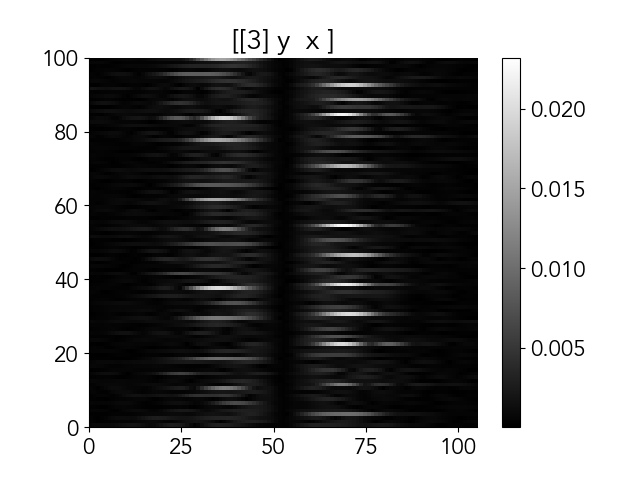

In [103]:
pl.ImagePlot(k_pred[:,:100,50:-50], colormap="gray")

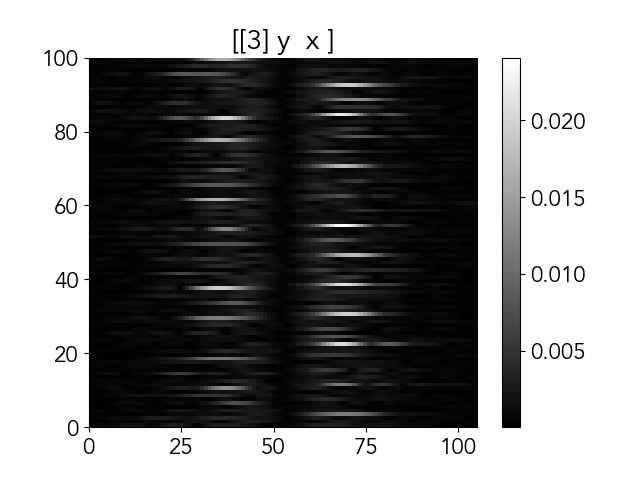

In [100]:
pl.ImagePlot(xk_actual[:,:100,50:-50], colormap="gray")

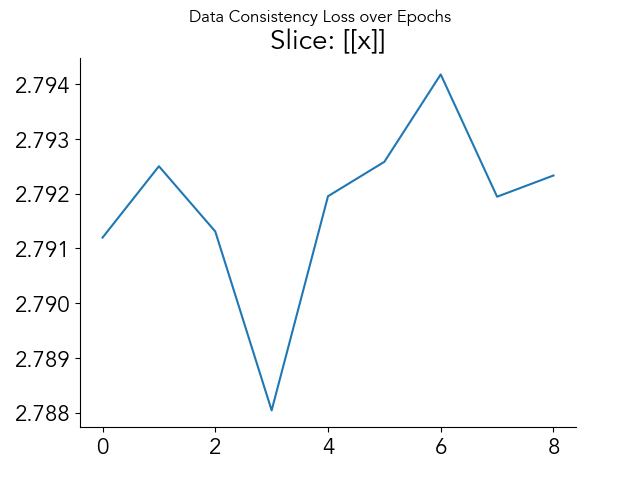

In [69]:
import numpy as np
pl.LinePlot(np.array(optimizer.dc_loss_log), title="Data Consistency Loss over Epochs")

# Visualize Motion
## Reconstruct calibration motion fields

In [79]:
optimizer.out_dir, os.path.dirname(optimizer.out_dir)

('/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/mrmotus',
 '/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib')

In [81]:
from bpt_motus.recon import MotionFieldWarp

calib_warp = MotionFieldWarp(
    model_dir = os.path.join(os.path.dirname(optimizer.out_dir), 'bpt_motus'), # optimizer.out_dir,
    ref_dir = nomotion_ref.save_dir, 
    out_dir = None, 
    bpts_dir = split_exp.calib_dir,
    force_reload = True,
)
calib_warp.run()

INFO: Loaded optimization config from /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus/optimization_params.json
INFO: Loading reference from /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/no_motion/crop_3/S_reference.npy (type: s_target)
INFO: Loading fully sampled motion fields from /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus/motion_fields.npy
INFO: Running motion field warping...
Warping frames: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 146/146 [03:04<00:00,  1.27s/it]
INFO: Saved warped frames to /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus/warped_s_target_frames.npy and motion fields to /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus/motion_fields.npy.


In [50]:
calib_warp.clear_data()

INFO: Clearing variables to free up memory (including CUDA cache if applicable)...


## Reconstruct inference motion fields

In [4]:
from bpt_motus.recon import MotionFieldWarp

model_dir = "/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/calib/bpt_motus"
nomotion_dir = "/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/no_motion/crop_3/"
inf_dir = "/mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf/"

calib_warp = MotionFieldWarp(
    model_dir = model_dir,
    ref_dir = nomotion_dir, 
    out_dir = None, 
    bpts_dir = inf_dir,
    phase = 'inf',
)
calib_warp.run()

INFO: Loading existing warped frames from /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf/warped_s_target_frames.npy and motion fields from /mikLKS/rinbha/BPT/MRMOTUS/example_data/bpt_motus/calib_inf/calib_hr_20000_35000_inf_hr_35000_None/inf/motion_fields.npy.


In [6]:
calib_warp.warped_frames.shape, calib_warp.full_motion_field.shape

(torch.Size([45, 135, 135, 135]), torch.Size([45, 135, 135, 135, 3]))

## Plot warped images and motion fields

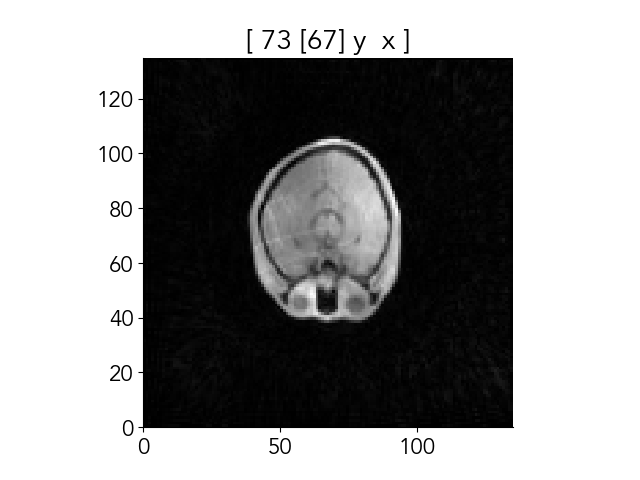

In [83]:
from bpt_motus.viz import ImageQuiverPlot
iqp = ImageQuiverPlot(calib_warp.warped_frames.detach().cpu().numpy(), calib_warp.full_motion_field.detach().cpu().numpy(), step=10, scale=50, apply_mask=True, mask_thresh=0.01)

# Error Evaluation
## Run PICS reconstructions

In [ ]:
from bpt_motus.recon import PICSRecon

pics_c = PICSRecon(inp_dir=calib_dir, verbose=True)
pics_c.run()

pics_i = PICSRecon(inp_dir=inf_dir, verbose=True)
pics_i.run()

## Apply forward warp to PICS

In [ ]:
# Apply the learned motion fields to warp the baseline PICS reconstructions
# warp_pics = MotionFieldWarp(model_dir=calib_dir, recon_dir=calib_dir)
# warp_pics.run(apply_to_pics=True)

## Voxel-wise Registration

In [ ]:
from bpt_motus.recon import ElastixRegistration

# Perform registration on both calibration and inference datasets using PICS as the reference grid
reg_c = ElastixRegistration(inp_dir=calib_dir, reference='pics', verbose=True)
reg_c.run()

reg_i = ElastixRegistration(inp_dir=inf_dir, reference='pics', verbose=True)
reg_i.run()

## Error Metrics Evaluation

In [ ]:
from bpt_motus.recon import ErrorEvaluator

# Compute and plot alignment errors, outputting voxel-wise RMSE and rigid transform params
evaluator = ErrorEvaluator(calib_dir=calib_dir, inf_dir=inf_dir, verbose=True)
evaluator.run()
evaluator.plot_metrics()